# Complaint Copilot — Part 1: Ingest & Explore

Pulls real consumer complaints from the **CFPB Consumer Complaint Database** public Open Data API
(free, no key required, updates daily) and does light exploration.

- Data source: https://www.consumerfinance.gov/data-research/consumer-complaints/
- API docs: https://cfpb.github.io/ccdb5-api/

If you have no internet (or the API is down), the notebook falls back to a small built-in
synthetic sample so every cell still runs.

In [ ]:
# Run once if needed:
# %pip install requests pandas pyarrow matplotlib

In [ ]:
import os, json
import requests
import pandas as pd

# --- Config ---
API_URL = "https://www.consumerfinance.gov/data-research/consumer-complaints/search/api/v1/"
N_COMPLAINTS = 200          # how many to pull for a quick run
PRODUCT = None              # e.g. "Credit reporting..." or None for all products
DATE_MIN = "2024-01-01"     # YYYY-MM-DD
HAS_NARRATIVE = True        # only complaints that include a free-text narrative
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

In [ ]:
def _sample_rows():
    # Synthetic fallback data so the notebook runs with no network. NOT real CFPB data.
    return [
        {"complaint_id":"S-0001","date_received":"2024-03-02","product":"Credit reporting","sub_product":"Credit reporting","issue":"Incorrect information on your report","sub_issue":"Account is not mine","company":"Acme Bureau","state":"WA","company_response":"Closed with explanation","timely":"Yes","complaint_what_happened":"I reported a fraudulent account three times but the bureau keeps saying it is verified and never explains how they verified it. This account is not mine and is hurting my score."},
        {"complaint_id":"S-0002","date_received":"2024-03-04","product":"Credit reporting","sub_product":"Credit reporting","issue":"Incorrect information on your report","sub_issue":"Old information reappears","company":"Acme Bureau","state":"CA","company_response":"Closed with explanation","timely":"Yes","complaint_what_happened":"A paid collection is still showing as open after 60 days even though I sent the confirmation letter that it was settled in full."},
        {"complaint_id":"S-0003","date_received":"2024-02-19","product":"Debt collection","sub_product":"Other debt","issue":"Attempts to collect debt not owed","sub_issue":"Debt is not yours","company":"Recovery Partners","state":"TX","company_response":"Closed with non-monetary relief","timely":"No","complaint_what_happened":"There was no response from the company for over a month after I disputed the amount owed. They keep adding fees that were never explained."},
        {"complaint_id":"S-0004","date_received":"2024-02-22","product":"Debt collection","sub_product":"Credit card debt","issue":"Communication tactics","sub_issue":"Frequent or repeated calls","company":"Recovery Partners","state":"FL","company_response":"Closed with explanation","timely":"Yes","complaint_what_happened":"They kept calling me about a debt I already settled. The file was never closed and I get calls multiple times a day."},
        {"complaint_id":"S-0005","date_received":"2024-03-10","product":"Mortgage","sub_product":"Conventional home mortgage","issue":"Trouble during payment process","sub_issue":"Escrow","company":"HomeServe Bank","state":"WA","company_response":"Closed with explanation","timely":"Yes","complaint_what_happened":"My mortgage servicer changed my escrow and doubled my payment without any notice. When I call, no one can explain the new amount."},
        {"complaint_id":"S-0006","date_received":"2024-03-12","product":"Mortgage","sub_product":"FHA mortgage","issue":"Applying for a mortgage","sub_issue":"Delays","company":"HomeServe Bank","state":"OR","company_response":"Closed with explanation","timely":"Yes","complaint_what_happened":"The loan officer lost my documents twice and the closing was delayed by weeks, which almost cost me the house."},
        {"complaint_id":"S-0007","date_received":"2024-03-15","product":"Money transfer","sub_product":"Mobile wallet","issue":"Fraud or scam","sub_issue":"Money sent to wrong person","company":"PayQuick","state":"NY","company_response":"Closed with explanation","timely":"Yes","complaint_what_happened":"I sent money to the wrong person through the app and support says nothing can be done to recover it. There is no way to reverse the transfer."},
        {"complaint_id":"S-0008","date_received":"2024-03-16","product":"Money transfer","sub_product":"Mobile wallet","issue":"Other transaction problem","sub_issue":"Transfer not received","company":"PayQuick","state":"GA","company_response":"In progress","timely":"Yes","complaint_what_happened":"The transfer was marked complete but the recipient never received it. It has been a week and the funds are just gone."},
        {"complaint_id":"S-0009","date_received":"2024-02-28","product":"Credit card","sub_product":"General purpose card","issue":"Problem with a purchase shown on statement","sub_issue":"Billing dispute","company":"Metro Card","state":"IL","company_response":"Closed with monetary relief","timely":"Yes","complaint_what_happened":"I was charged twice for the same purchase and the billing dispute was denied without any real review of the evidence I uploaded."},
        {"complaint_id":"S-0010","date_received":"2024-03-01","product":"Credit card","sub_product":"Store card","issue":"Fees or interest","sub_issue":"Unexpected interest","company":"Metro Card","state":"WA","company_response":"Closed with explanation","timely":"Yes","complaint_what_happened":"They charged me interest even though I paid the full statement balance before the due date. The interest keeps compounding."},
        {"complaint_id":"S-0011","date_received":"2024-03-20","product":"Student loan","sub_product":"Federal student loan servicing","issue":"Dealing with your lender or servicer","sub_issue":"Payment not applied","company":"EduServ","state":"PA","company_response":"Closed with explanation","timely":"Yes","complaint_what_happened":"My payments are not being applied to the principal and the servicer keeps putting me in forbearance that I never requested."},
        {"complaint_id":"S-0012","date_received":"2024-03-21","product":"Checking account","sub_product":"Checking account","issue":"Managing an account","sub_issue":"Funds not available","company":"First River Bank","state":"WA","company_response":"Closed with explanation","timely":"No","complaint_what_happened":"The bank placed a hold on my deposit for ten days with no explanation and I could not pay my rent because of it."},
        {"complaint_id":"S-0013","date_received":"2024-03-22","product":"Credit reporting","sub_product":"Credit reporting","issue":"Improper use of your report","sub_issue":"Hard inquiry","company":"Acme Bureau","state":"NV","company_response":"Closed with explanation","timely":"Yes","complaint_what_happened":"There are several hard inquiries on my report that I never authorized. I think someone is using my identity to open accounts."},
        {"complaint_id":"S-0014","date_received":"2024-03-25","product":"Money transfer","sub_product":"International transfer","issue":"Other transaction problem","sub_issue":"Excessive fees","company":"PayQuick","state":"CA","company_response":"Closed with explanation","timely":"Yes","complaint_what_happened":"The exchange rate and hidden fees took almost 15 percent of what I sent abroad and none of it was disclosed up front."},
    ]

In [ ]:
def fetch_complaints(n=N_COMPLAINTS, product=PRODUCT, date_min=DATE_MIN, has_narrative=HAS_NARRATIVE):
    params = {
        "size": n,
        "format": "json",
        "date_received_min": date_min,
        "sort": "created_date_desc",
    }
    if has_narrative:
        params["has_narrative"] = "true"
    if product:
        params["product"] = product
    try:
        r = requests.get(API_URL, params=params, timeout=30)
        r.raise_for_status()
        payload = r.json()
        hits = payload.get("hits", {}).get("hits", [])
        rows = [h.get("_source", {}) for h in hits]
        if rows:
            print("Fetched", len(rows), "complaints from the CFPB API.")
        else:
            print("API returned no rows; using built-in sample.")
            rows = _sample_rows()
    except Exception as e:
        print("API request failed (", e, ") -- using built-in sample so the notebook still runs.")
        rows = _sample_rows()
    return rows

raw = fetch_complaints()
print("rows:", len(raw))

API request failed ( 403 Client Error: Forbidden for url: https://www.consumerfinance.gov/data-research/consumer-complaints/search/api/v1/?size=200&format=json&date_received_min=2024-01-01&sort=created_date_desc&has_narrative=true ) -- using built-in sample so the notebook still runs.
rows: 14


In [ ]:
df = pd.DataFrame(raw)

keep = ["complaint_id","date_received","product","sub_product","issue","sub_issue",
        "company","state","company_response","timely","complaint_what_happened"]
for col in keep:
    if col not in df.columns:
        df[col] = None

df = df[keep].rename(columns={"complaint_what_happened": "narrative"})
df = df[df["narrative"].notna()]
df = df[df["narrative"].astype(str).str.len() > 0].reset_index(drop=True)
print("complaints with narratives:", len(df))
df.head(3)

complaints with narratives: 14


,complaint_id,date_received,product,sub_product,issue,sub_issue,company,state,company_response,timely,narrative
0,S-0001,2024-03-02,Credit reporting,Credit reporting,Incorrect information on your report,Account is not mine,Acme Bureau,WA,Closed with explanation,Yes,I reported a fraudulent account three times bu...
1,S-0002,2024-03-04,Credit reporting,Credit reporting,Incorrect information on your report,Old information reappears,Acme Bureau,CA,Closed with explanation,Yes,A paid collection is still showing as open aft...
2,S-0003,2024-02-19,Debt collection,Other debt,Attempts to collect debt not owed,Debt is not yours,Recovery Partners,TX,Closed with non-monetary relief,No,There was no response from the company for ove...


In [ ]:
print("Top products:")
print(df["product"].value_counts().head(10))
print()
print("Narrative length (chars):")
print(df["narrative"].astype(str).str.len().describe())

Top products:
product
Credit reporting    3
Money transfer      3
Debt collection     2
Mortgage            2
Credit card         2
Student loan        1
Checking account    1
Name: count, dtype: int64

Narrative length (chars):
count     14.000000
mean     127.428571
std       16.850995
min      110.000000
25%      117.000000
50%      124.000000
75%      128.750000
max      177.000000
Name: narrative, dtype: float64


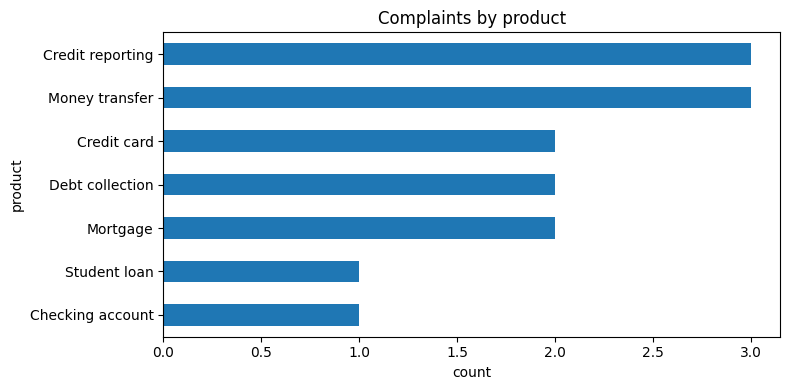

In [ ]:
import matplotlib.pyplot as plt
top = df["product"].value_counts().head(8)
ax = top.sort_values().plot(kind="barh", figsize=(8, 4))
ax.set_title("Complaints by product")
ax.set_xlabel("count")
plt.tight_layout()
plt.show()

In [ ]:
out = os.path.join(DATA_DIR, "complaints.parquet")
df.to_parquet(out, index=False)
print("Saved", len(df), "complaints to", out)

Saved 14 complaints to data/complaints.parquet


**Next:** open `02_copilot_rag.ipynb` to extract structured fields with an LLM,
build embeddings, and run the RAG query engine.